# Importing packages

In [1]:
import os
from pathlib import Path
from functools import partial

import numpy as np

import rasterio
from rasterio.plot import reshape_as_image, reshape_as_raster
from rasterio.warp import reproject, calculate_default_transform, Resampling

import torch
import omnicloudmask
from omnicloudmask import predict_from_array

import matplotlib
from matplotlib import pyplot as plt

# Loading imagery

In [2]:
## WV2, WV3, WV Legion
sat = 'lg' # wv2, wv3, lg
img_path = r"T:\Sumesh\RD\004_Cloud_Masking\case_study\2_OB32\26APR24033446-M2AS-050473894010_01_P007_ortho_EPSG28350_gcp.tif"
if sat == 'lg':
    band_indices = [5, 3, 2, 8] # R, G, B, NIR
elif sat == 'wv2' or sat == 'wv3':
    band_indices = [5, 3, 2, 7] # R, G, B, NIR

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 5587, 'height': 10452, 'count': 8, 'crs': CRS.from_wkt('PROJCS["GDA94 / MGA zone 50",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28350"]]'), 'transform': Affine(1.5999999999999917, 0.0, 787425.1005351929,
       0.0, -1.6000000000000179, 7425736.853912738), 'blockxsize': 5587, 'blockysize': 128, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35919052..9.245595].


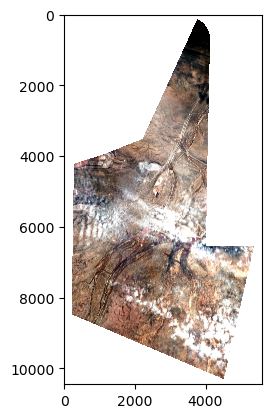

In [3]:
with rasterio.open(img_path) as ds:
    print(ds.profile)
    nodata = ds.nodata
    img_arr = ds.read()

temp_img_arr = img_arr.copy().astype(np.float32)
temp_img_arr[temp_img_arr == nodata] = np.nan
temp_img_arr = temp_img_arr/10000
for i in range(temp_img_arr.shape[0]):
    temp_img_arr[i] = (temp_img_arr[i] - np.nanquantile(temp_img_arr[i], 0.02)) / (np.nanquantile(temp_img_arr[i], 0.98) - np.nanquantile(temp_img_arr[i], 0.02))

plt.imshow(reshape_as_image(temp_img_arr)[:,:,[2, 1, 0]]*1.5)
plt.show()

# Cloud and cloud shadows detection

## Downsampling imagery to 10 m
OmniCloudMask models are designed to work with imagery from 10 m to 50 m as shown in figure below.

![](https://omnicloudmask.readthedocs.io/en/latest/_images/resolution_guide.svg)

**Higher resolution doesn’t always mean higher accuracy**

Cloud and shadow detection relies on texture and spatial relationships across a scene. Below roughly 10 m there is little additional information the model can use, so feeding it 5 m or finer imagery adds compute without adding accuracy. What matters far more than fine resolution is having enough surrounding `spatial context`.

In [4]:
# image resolution in meters
TARGET_RES = 10
with rasterio.open(img_path) as ds:
    profile = ds.profile
    print(profile)
    res = ds.res[0]
    nodata = profile['nodata']
    img_arr = ds.read(indexes = band_indices)
    if res < TARGET_RES:
        # warping from res to TARGET_RES
        img_arr, out_transform = reproject(source = img_arr,
                                           src_transform = ds.transform,
                                           src_crs = ds.crs,
                                           dst_crs = ds.crs,
                                           resampling = Resampling.cubic, # cubic, bilinear
                                           dst_resolution = (TARGET_RES, TARGET_RES), 
                                           src_nodata = nodata,
                                           dst_nodata = nodata)    
    print('Image shape: {}'.format(img_arr.shape))

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 5587, 'height': 10452, 'count': 8, 'crs': CRS.from_wkt('PROJCS["GDA94 / MGA zone 50",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28350"]]'), 'transform': Affine(1.5999999999999917, 0.0, 787425.1005351929,
       0.0, -1.6000000000000179, 7425736.853912738), 'blockxsize': 5587, 'blockysize': 128, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}
Image shape: (4, 1673, 894)


## Detecting cloud and cloud shadows

In [5]:
# running omnicloudmask
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: {}'.format(device))

# choose large patch size for improving thin cloud and cloud shadow detection, and set some overlap to mitigate edge artifacts
patch_size = 1000
patch_overlap = 300 

# input array should be in the order of R, G, NIR
mask = predict_from_array(input_array = img_arr[[2, 1, 3]], patch_size = patch_size, patch_overlap = patch_overlap, batch_size = 1,
                          inference_device = device, mosaic_device = device, inference_dtype = torch.float32,
                          no_data_value = nodata, apply_no_data_mask = True) 

Device: cuda


c:\Users\Sumesh.kc\AppData\Local\anaconda3\envs\python312\Lib\site-packages\omnicloudmask\cloud_mask.py:274: UserWarning: Significant no-data areas detected. Adjusting patch size to 447px and overlap to 223px to minimize no-data patches.
  patch_overlap, patch_size = check_patch_size(


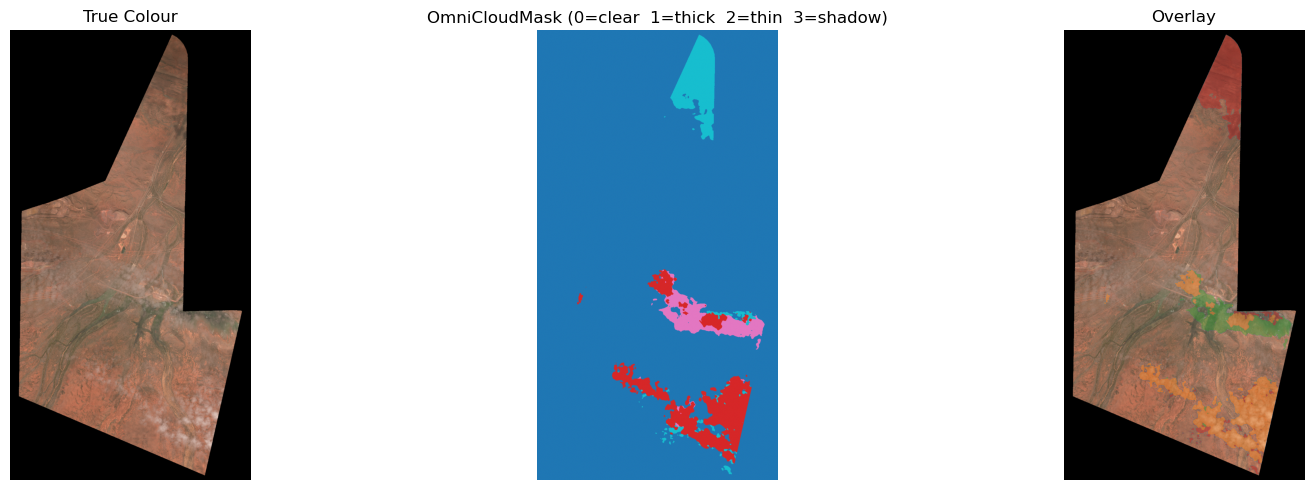

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rgb_display = np.power(img_arr[[0, 1, 2]].astype("float32"), 0.5)
rgb_display = (rgb_display - rgb_display.min()) / (
    rgb_display.max() - rgb_display.min()
)
rgb_display = np.clip(rgb_display, 0, 1).transpose(1, 2, 0)

axes[0].imshow(rgb_display)
axes[0].set_title("True Colour")
axes[0].axis("off")

axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb_display)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# printing the proportion of cloud and cloud shadows
print("Clear pixels (0): {:.2f} %".format(np.sum(mask == 0) / mask.size * 100))
print("Thick cloud pixels (1): {:.2f} %".format(np.sum(mask == 1) / mask.size * 100))
print("Thin cloud pixels (2): {:.2f} %".format(np.sum(mask == 2) / mask.size * 100))
print("Cloud shadow pixels (3): {:.2f} %".format(np.sum(mask == 3) / mask.size * 100))

Clear pixels (0): 90.89 %
Thick cloud pixels (1): 4.47 %
Thin cloud pixels (2): 1.80 %
Cloud shadow pixels (3): 2.84 %


## Masking cloud and cloud shadows
* Resample cloud and cloud shadows mask from 10 m to original pixel resolution of input WorldView imagery,  apply resampled mask to the original imagery and save the masked raster layer.

In [13]:
# applying mask and saving the results
with rasterio.open(img_path) as ds:
    profile = ds.profile
    print(profile)
    res = ds.res[0]
    nodata = profile['nodata']

    profile.update({'tiled': True, 
                    'compress': 'lzw',
                    'blockxsize': 1024, 
                    'blockysize': 1024})

    # apply the mask to all bands
    img_arr = ds.read()
    mask_img_arr = ds.read_masks(1)

    # need to reproject the mask back to the original resolution and extent
    out_mask_sq = np.empty(img_arr.shape[1:], dtype = mask_sq.dtype)
    if mask_sq.shape < img_arr.shape[1:]:
        print('Dimensions of mask and image do not match, reprojecting the mask back to the original resolution and extent...') 
        reproject(source = mask_sq,
                  destination = out_mask_sq,
                  src_transform = out_transform,
                                  dst_transform = ds.transform,
                                  src_crs = ds.crs,
                                  dst_crs = ds.crs,
                                  dst_width = out_mask_sq.shape[1],
                                  dst_height = out_mask_sq.shape[0],
                                  resampling = Resampling.nearest,
                                  dst_resolution = (res, res), 
                                  src_nodata = nodata,
                                  dst_nodata = nodata) 
        print('Reprojected mask shape: {}'.format(out_mask_sq.shape))

    # set masked pixels to nodata value
    masked_arr = np.where((out_mask_sq == 0) & (ds.read(1) != nodata), img_arr, nodata)

    # saving masked raster
    out_img_path = os.path.splitext(img_path)[0] + '_cloud_masked.tif'
    print('Output raster" {}'.format(out_img_path))
    # if not os.path.exists(out_img_path):
    with rasterio.open(out_img_path, 'w', **profile) as dst:
        dst.write(masked_arr)

    # saving mask raster
    out_mask_sq = np.where((mask_img_arr > 0), out_mask_sq, 255)
    mask_profile = profile.copy()
    mask_profile.update({'count': 1, 'dtype': out_mask_sq.dtype, 'nodata': 255}) # changing nodata value to 255 for the mask, as 0 is a valid class in the mask
    out_mask_path = os.path.splitext(img_path)[0] + '_cloud_mask.tif'
    # if not os.path.exists(out_mask_path):
    with rasterio.open(out_mask_path, 'w', **mask_profile) as dst:
        dst.write(out_mask_sq, 1)

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 5587, 'height': 10452, 'count': 8, 'crs': CRS.from_wkt('PROJCS["GDA94 / MGA zone 50",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28350"]]'), 'transform': Affine(1.5999999999999917, 0.0, 787425.1005351929,
       0.0, -1.6000000000000179, 7425736.853912738), 'blockxsize': 5587, 'blockysize': 128, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}
Dimensions of mask and image do not match, reprojecting